In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Ejercicio N°5**

El dataset `wine_quality.xlsx` contiene información acerca del puntaje que un panel de enólogos
asignó a una serie de 76 vinos de tipo Pinot Noir. Las cualidades evaluadas incluyeron algunas
propiedades organolépticas como claridad (*clarity*), aroma (*aroma*), cuerpo (*body*) y sabor (*flavor*) y una valoración de la calidad general del vino (*quality*). Adicionalmente, se recabó información sobre el grado de envejecimiento (*aging*) de cada uno de los productos evaluados, la cual se encuentra en el dataset `wine_aging.csv`.

1. Importe ambos datasets y realice cualquier tarea de limpieza y adecuación de los mismos que
considere necesaria para su posterior análisis.

In [3]:
vino_calidad=pd.read_excel('./datasets/wine_quality.xlsx', header=2)
vino_calidad.head()

,id,clarity,aroma,body,flavor,quality
0,1,1.0,3.3,2.8,3.1,9;8
1,2,1.0,4.4,4.9,3.5,12;6
2,3,1.0,3.9,5.3,4.8,11;9
3,4,1.0,3.9,2.6,3.1,11;1
4,4,1.0,3.9,2.6,3.1,11;1


In [4]:
vino_calidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       77 non-null     int64  
 1   clarity  77 non-null     float64
 2   aroma    77 non-null     float64
 3   body     77 non-null     float64
 4   flavor   77 non-null     float64
 5   quality  77 non-null     object 
dtypes: float64(4), int64(1), object(1)
memory usage: 3.7+ KB


In [5]:
vino_calidad['quality']=vino_calidad['quality'].str.replace(';','.').astype(float)
vino_calidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       77 non-null     int64  
 1   clarity  77 non-null     float64
 2   aroma    77 non-null     float64
 3   body     77 non-null     float64
 4   flavor   77 non-null     float64
 5   quality  77 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 3.7 KB


In [6]:
vino_edad=pd.read_csv('./datasets/wine_aging.csv',sep=';')
vino_edad.head()

,WINE_id,aging
0,1,crianza
1,2,crianza
2,3,reserva
3,4,crianza
4,5,gran reserva


In [7]:
vino_edad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   WINE_id  76 non-null     int64 
 1   aging    76 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.3+ KB


Combinacion de ambos datasets segun el wine_id e id

In [8]:
vinos=pd.merge(vino_edad,vino_calidad,left_on='WINE_id', right_on='id')
vinos=vinos.drop(columns='id')
vinos.head()

,WINE_id,aging,clarity,aroma,body,flavor,quality
0,1,crianza,1.0,3.3,2.8,3.1,9.8
1,2,crianza,1.0,4.4,4.9,3.5,12.6
2,3,reserva,1.0,3.9,5.3,4.8,11.9
3,4,crianza,1.0,3.9,2.6,3.1,11.1
4,4,crianza,1.0,3.9,2.6,3.1,11.1


2. ¿Cuál es el tipo de vino (crianza/reserva/gran reserva) que presenta la mayor mediana para el sabor?

In [9]:
#mayor mediana para el sabor
mediana_sabor=vinos.groupby('aging')['flavor'].mean().idxmax()
print(f'El tipo de vino con mayor mediana para el sabor es: {mediana_sabor}')

El tipo de vino con mayor mediana para el sabor es: gran reserva


3. Construya la matriz de covariancia de las distintas variables cuantitativas que componen el
dataset y comente qué tipo de información le aporta acerca de la relación entre los distintos
pares de variables cuantitativas del dataset.

<Axes: >

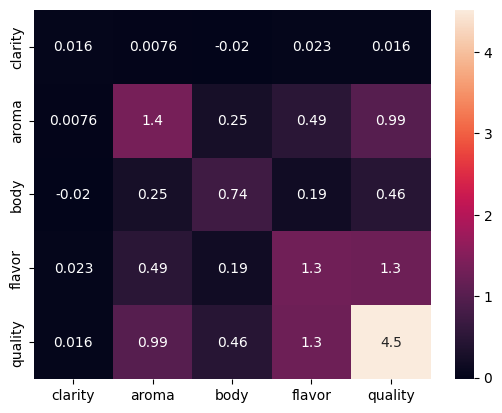

In [10]:
col_numericas=['clarity','aroma','body','flavor','quality']
#matriz covariancia
cov_mat=vinos[col_numericas].cov()
sns.heatmap(data=cov_mat,annot=True)

4. Construya la matriz de correlación de las distintas variables cuantitativas que componen el
dataset. En base al mismo, identifique la/s variable/s que se encuentran más fuertemente
correlacionadas e informe e interprete la medida de asociación lineal correspondiente

<Axes: >

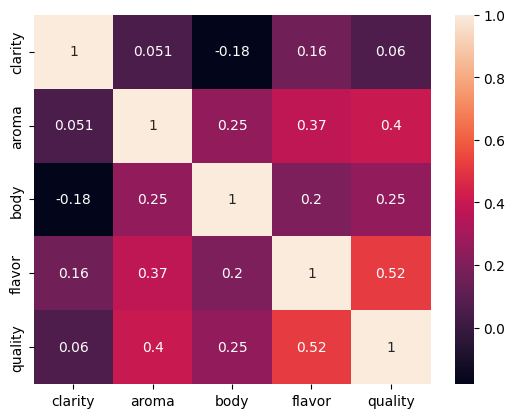

In [11]:
#matriz correlacion
corr_mat=vinos[col_numericas].corr()
sns.heatmap(data=corr_mat,annot=True)

como los r estan maximo en 0.52, podemos decir que hay relacion debil entre las variables

5. Elija el par de variables que identificó en el ítem anterior como aquellas que se encuentran más fuertemente correlacionadas linealmente y realice un gráfico que le permita visualizar la relación general que existe entre las mismas.

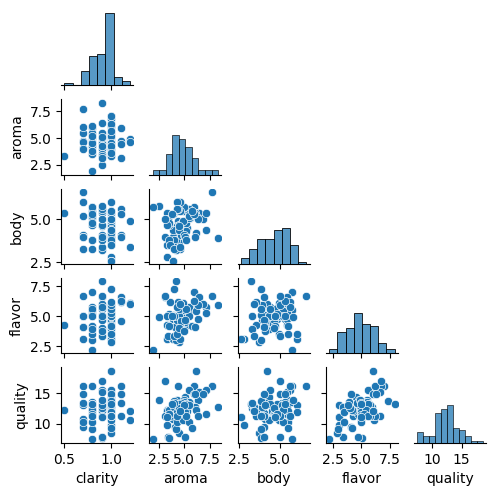

In [12]:
# 1. Le pasamos a Seaborn nuestro DataFrame que ya tiene SOLO números
# (Opcional pero recomendado: corner=True borra la mitad superior del gráfico 
# para no ver los mismos scatterplots repetidos como en un espejo)
sns.pairplot(vinos[col_numericas],  corner=True, height=1)

# 2. Mostramos el gráfico
plt.show()